# Classification

<a target="_blank" href="https://colab.research.google.com/github/mmadoliat/SML-s26/blob/main/code/Classification.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Linear Discriminant Analysis

Accuracy: 1.0000

Confusion matrix:
 [[12  0  0]
 [ 0 13  0]
 [ 0  0 13]] 



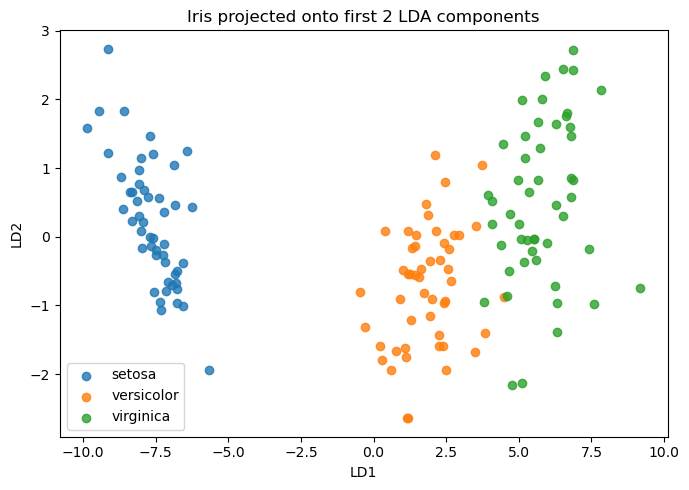

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1) Load Iris data
iris = load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names

# 2) Train/test split (stratify keeps class proportions)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# 3) Fit LDA classifier
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

# 4) Evaluate
y_pred = lda.predict(X_test)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {acc:.4f}\n")
print("Confusion matrix:\n", cm, "\n")

# 5) Project data to 2D using LDA for visualization
#    (Iris has 3 classes => at most 2 LDA components)
X_lda = lda.fit(X, y).transform(X)

plt.figure(figsize=(7, 5))
for cls in np.unique(y):
    plt.scatter(
        -X_lda[y == cls, 0],
        -X_lda[y == cls, 1],
        label=target_names[cls],
        alpha=0.8
    )

plt.title("Iris projected onto first 2 LDA components")
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.legend()
plt.tight_layout()
plt.show()


# ROC curve

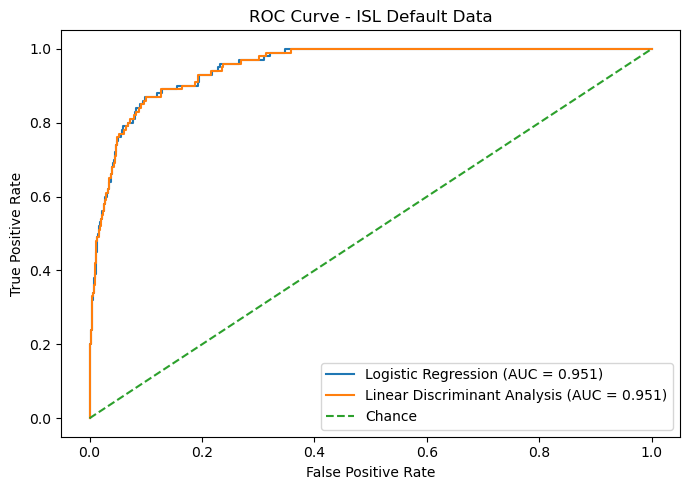

Logistic Reg. AUC: 0.9511
LDA AUC: 0.9508


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# pip install uv && uv pip install ISLP
from ISLP import load_data

# 1) Load ISL Default dataset
df = load_data('Default')

# 2) Encode target (Yes/No -> 1/0)
df["default"] = df["default"].map({"Yes": 1, "No": 0})

# 3) Separate features and target
X = df[["balance", "income", "student"]]
y = df["default"]

# 4) One-hot encode the 'student' variable
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first"), ["student"])
    ],
    remainder="passthrough"
)

X = preprocessor.fit_transform(X)

# 5) Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 6) Fit logistic regression
model1 = LogisticRegression(max_iter=1000)
model2 = LinearDiscriminantAnalysis()
model1.fit(X_train, y_train)
model2.fit(X_train, y_train)

# 7) Get predicted probabilities
y_prob1 = model1.predict_proba(X_test)[:, 1]
y_prob2 = model2.predict_proba(X_test)[:, 1]

# 8) Compute ROC curve
fpr1, tpr1, thresholds1 = roc_curve(y_test, y_prob1)
roc_auc1 = auc(fpr1, tpr1)

fpr2, tpr2, thresholds2 = roc_curve(y_test, y_prob2)
roc_auc2 = auc(fpr2, tpr2)

# 9) Plot ROC
plt.figure(figsize=(7, 5))
plt.plot(fpr1, tpr1, label=f"Logistic Regression (AUC = {roc_auc1:.3f})")
plt.plot(fpr2, tpr2, label=f"Linear Discriminant Analysis (AUC = {roc_auc2:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Chance")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - ISL Default Data")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Logistic Reg. AUC: {roc_auc1:.4f}")
print(f"LDA AUC: {roc_auc2:.4f}")